# CofC COUG Table — PDF-Based Scoring (Legacy)

> ⚠️ **Legacy pipeline** — parses Wyscout player PDFs to compute COUG scores.
> Used for 2025 season backfill only. For 2026 onward, use the XML pipeline
> (`CofC_COUGS_Pipeline_Stage1.ipynb`) which produces richer, more accurate data.
> Scores produced here use provisional `trial_1` weights — not yet coach-confirmed.

Parses Wyscout player PDFs and computes ASET / PEAK / Set Piece scores for each player.


In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Notebook lives at pipeline/notebooks/ — go up one level to pipeline/, then into analytics/
notebook_dir = os.path.abspath('')
src_path = os.path.normpath(os.path.join(notebook_dir, '..', 'analytics'))
sys.path.insert(0, src_path)

print(f'src path: {src_path}')
print(f'Exists:   {os.path.exists(src_path)}')

from config import PLAYER_INGEST_DIR, COUG_TABLE_DIR
from coug_table import parse_match_pdf, build_season_coug_table


COFC_COLOR = '#6B0032'
OPP_COLOR  = '#A0A0A0'

print('\n✅ Imports OK')
print(f'Player PDF dir: {PLAYER_INGEST_DIR}')
print(f'Output dir:     {COUG_TABLE_DIR}')
print(f'Figures Dir:    {COUG_TABLE_DIR}/figures')

---
## Single Match — Quick Look
Parse one match PDF and show the COUG Table.

In [2]:
# Change filename to any PDF in your player_reports folder
MATCH_PDF = Path(PLAYER_INGEST_DIR) / 'players_2025_11_02_UNCW.pdf'

print(f'Parsing: {MATCH_PDF}')
print('=' * 60)

df_match = parse_match_pdf(str(MATCH_PDF))

# ── Build match_label from PDF filename (most reliable source) ──────────
# PDF naming convention: players_YYYY_MM_DD_Opponent.pdf
# Output convention:     coug_table_YYYY_MM_DD_Opponent.csv
# We always derive from filename to avoid inconsistencies from parsed data.
stem_parts = MATCH_PDF.stem.split('_')  # ['players', 'YYYY', 'MM', 'DD', 'Opponent']
if len(stem_parts) >= 5 and stem_parts[0] == 'players':
    match_label = '_'.join(stem_parts[1:5])  # 'YYYY_MM_DD_Opponent' — always 4 parts
else:
    # Fallback if filename doesn't follow convention — flag it
    match_label = MATCH_PDF.stem.replace('players_', '')
    print(f'⚠️  Unexpected filename format: {MATCH_PDF.name}')
    print(f'   Expected: players_YYYY_MM_DD_Opponent.pdf')
    print(f'   Output will be: coug_table_{match_label}.csv — rename manually if wrong')

print(f'Match label: {match_label}')

if df_match.empty:
    print('⚠ No player data extracted — check PDF path and format.')
else:
    print(f'{len(df_match)} players parsed\n')

    display_cols = ['player', 'goals', 'shots_on_target', 'interceptions',
                    'clearances', 'duels_won', 'aset_score', 'peak_score', 'total_score']
    available = [c for c in display_cols if c in df_match.columns]

    print('COUG TABLE')
    print('=' * 60)
    print(df_match[available].sort_values('total_score', ascending=False).to_string(index=False))


Parsing: /Users/anissawilliams/PycharmProjects/cofc_soccer_analytics_2026/pipeline/src/../data/raw/player_reports/players_2025_11_02_UNCW.pdf
19 players parsed

COUG TABLE
      player  goals  shots_on_target  interceptions  clearances  duels_won  aset_score  peak_score  total_score
 J. Jordheim      0                0              9           4         15        19.0         0.4         19.4
     N. Gold      0                0             14           2          6        16.0         0.0         16.0
     L. Gill      3                0              3           1         11         5.5         9.2         14.7
    E. White      1                1              6           1          7        11.0         3.7         14.7
 S. Bendvold      1                1              3           0          6         4.0         4.3          8.3
   M. Lenert      1                1              2           0         10         4.0         4.1          8.1
   H. Walker      0                0        

---
## Visualize Single Match

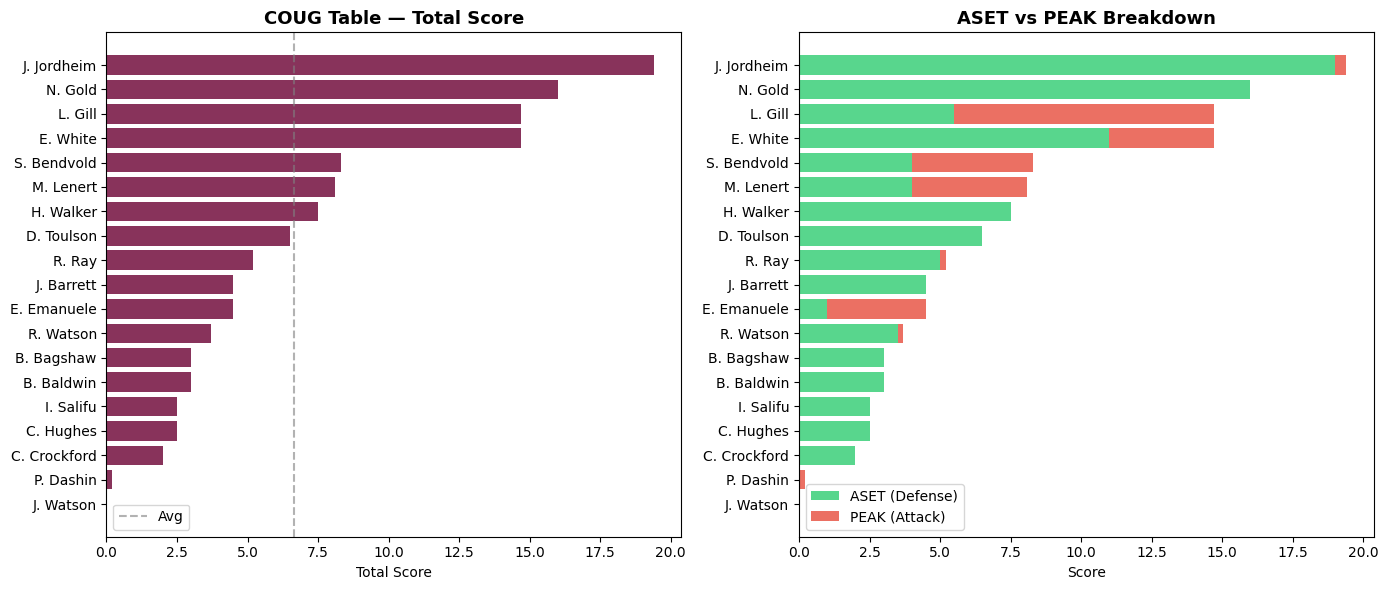

✅ Saved visualization


In [3]:
if not df_match.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Total score bar chart
    ax1 = axes[0]
    df_sorted = df_match.sort_values('total_score', ascending=True)
    ax1.barh(df_sorted['player'], df_sorted['total_score'], color=COFC_COLOR, alpha=0.8)
    ax1.set_title('COUG Table — Total Score', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Total Score')
    ax1.axvline(df_sorted['total_score'].mean(), color='gray',
                linestyle='--', alpha=0.6, label='Avg')
    ax1.legend()

    # ASET vs PEAK stacked
    ax2 = axes[1]
    df_sorted2 = df_match.sort_values('total_score', ascending=True)
    ax2.barh(df_sorted2['player'], df_sorted2['aset_score'],
             color='#2ecc71', alpha=0.8, label='ASET (Defense)')
    ax2.barh(df_sorted2['player'], df_sorted2['peak_score'],
             left=df_sorted2['aset_score'], color='#e74c3c', alpha=0.8, label='PEAK (Attack)')
    ax2.set_title('ASET vs PEAK Breakdown', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Score')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(COUG_TABLE_DIR + f'/figures/coug_table_{match_label}_viz.png', dpi=150, bbox_inches='tight')
    df_match.to_csv(COUG_TABLE_DIR + f'/coug_table_{match_label}.csv', index=False)
    #plt.savefig(COUG_TABLE_DIR + '/figures/coug_table_match_viz.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved visualization')

---
## Season Totals — All Matches
Process every PDF in the player_reports folder.

In [4]:
from pathlib import Path

pdf_files = sorted(Path(PLAYER_INGEST_DIR).glob('*.pdf'))
print(f'Found {len(pdf_files)} match PDFs:')
for f in pdf_files:
    print(f'  {f.name}')

Found 16 match PDFs:
  players_2025_08_03_Wofford.pdf
  players_2025_08_22_SouthCarolina.pdf
  players_2025_08_26_Davidson.pdf
  players_2025_09_02_NorthCarolina.pdf
  players_2025_09_06_Elon.pdf
  players_2025_09_10_USCUpstate.pdf
  players_2025_09_13_Campbell.pdf
  players_2025_09_17_Furman.pdf
  players_2025_09_24_GeorgiaSouthern.pdf
  players_2025_09_27_WilliamMary.pdf
  players_2025_10_05_Campbell.pdf
  players_2025_10_08_NorthFlorida.pdf
  players_2025_10_15_Winthrop.pdf
  players_2025_10_18_Elon.pdf
  players_2025_10_25_WilliamMary.pdf
  players_2025_11_02_UNCW.pdf


In [5]:
if pdf_files:
    print('Processing all match PDFs...')
    season_df, season_totals = build_season_coug_table(PLAYER_INGEST_DIR)

    print(f'\n{len(season_totals)} players in season dataset')
    print(f'{len(season_df)} total player-match rows')

    print('\n=== SEASON COUG TABLE ===')
    print(season_totals.to_string(index=False))

    season_totals.to_csv(COUG_TABLE_DIR + '/season_coug_table.csv', index=False)
    season_df.to_csv(COUG_TABLE_DIR + '/season_coug_table_by_match.csv', index=False)
    print('\n✅ Saved season totals')
else:
    print('No PDFs found — check PLAYER_INGEST_DIR in config.py')

Processing all match PDFs...
Processing: players_2025_08_03_Wofford.pdf
  → Saved coug_table_2025_08_03_Wofford.csv
Processing: players_2025_08_22_SouthCarolina.pdf
  → Saved coug_table_2025_08_22_SouthCarolina.csv
Processing: players_2025_08_26_Davidson.pdf
  → Saved coug_table_2025_08_26_Davidson.csv
Processing: players_2025_09_02_NorthCarolina.pdf
  → Saved coug_table_2025_09_02_NorthCarolina.csv
Processing: players_2025_09_06_Elon.pdf
  → Saved coug_table_2025_09_06_Elon.csv
Processing: players_2025_09_10_USCUpstate.pdf
  → Saved coug_table_2025_09_10_USCUpstate.csv
Processing: players_2025_09_13_Campbell.pdf
  → Saved coug_table_2025_09_13_Campbell.csv
Processing: players_2025_09_17_Furman.pdf
  → Saved coug_table_2025_09_17_Furman.csv
Processing: players_2025_09_24_GeorgiaSouthern.pdf
  → Saved coug_table_2025_09_24_GeorgiaSouthern.csv
Processing: players_2025_09_27_WilliamMary.pdf
  → Saved coug_table_2025_09_27_WilliamMary.csv
Processing: players_2025_10_05_Campbell.pdf
  → Sav

---
## Season Visualization

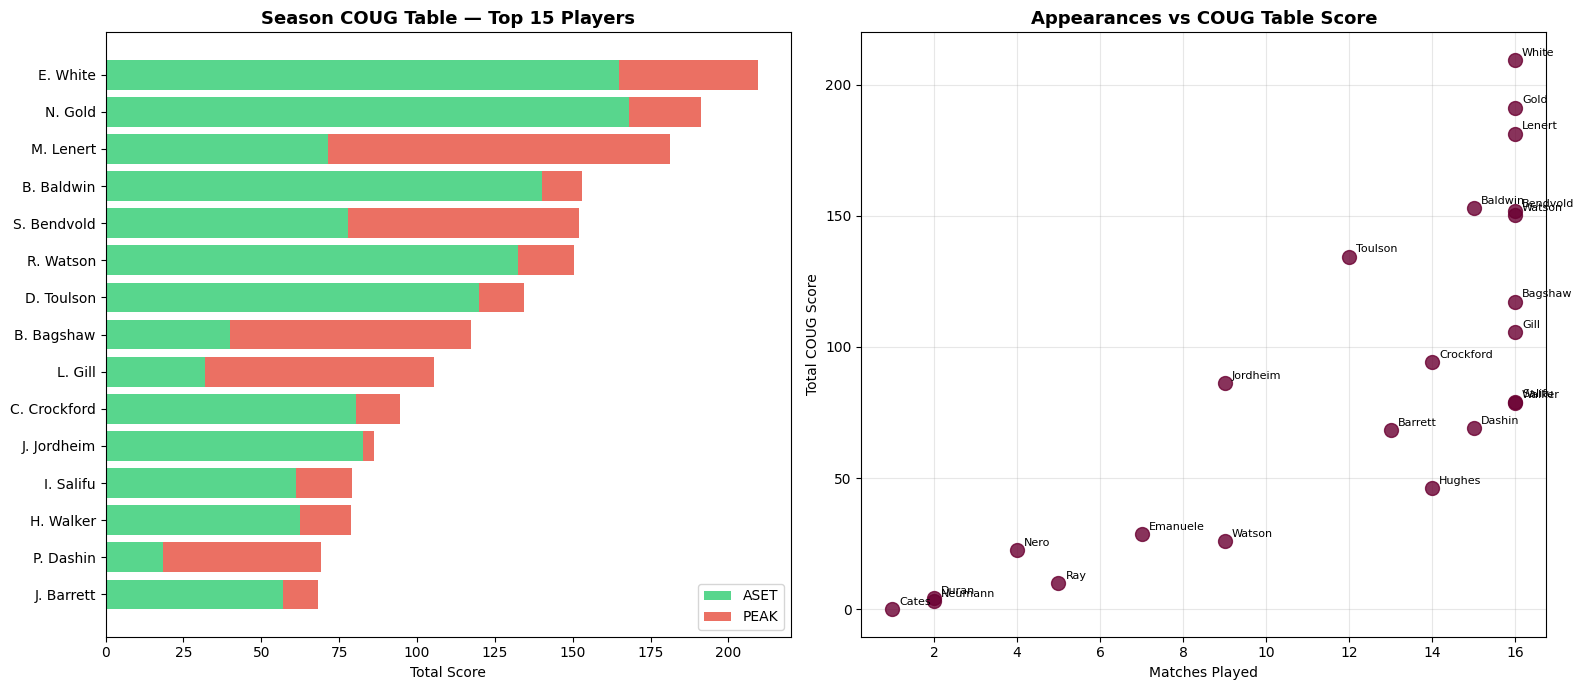

✅ Saved season visualization


In [6]:
if pdf_files and not season_totals.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Season total score stacked
    ax1 = axes[0]
    top = season_totals.head(15).sort_values('total_score', ascending=True)
    ax1.barh(top['player'], top['aset_score'], color='#2ecc71', alpha=0.8, label='ASET')
    ax1.barh(top['player'], top['peak_score'],
             left=top['aset_score'], color='#e74c3c', alpha=0.8, label='PEAK')
    ax1.set_title('Season COUG Table — Top 15 Players', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Total Score')
    ax1.legend()

    # Appearances vs score
    ax2 = axes[1]
    ax2.scatter(season_totals['matches'], season_totals['total_score'],
                color=COFC_COLOR, s=100, alpha=0.8, zorder=3)
    for _, row in season_totals.iterrows():
        ax2.annotate(row['player'].split('.')[-1].strip(),
                     (row['matches'], row['total_score']),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
    ax2.set_title('Appearances vs COUG Table Score', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Matches Played')
    ax2.set_ylabel('Total COUG Score')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(COUG_TABLE_DIR + '/figures/season_coug_table_viz.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved season visualization')

---
## Per-Match Trend — Single Player

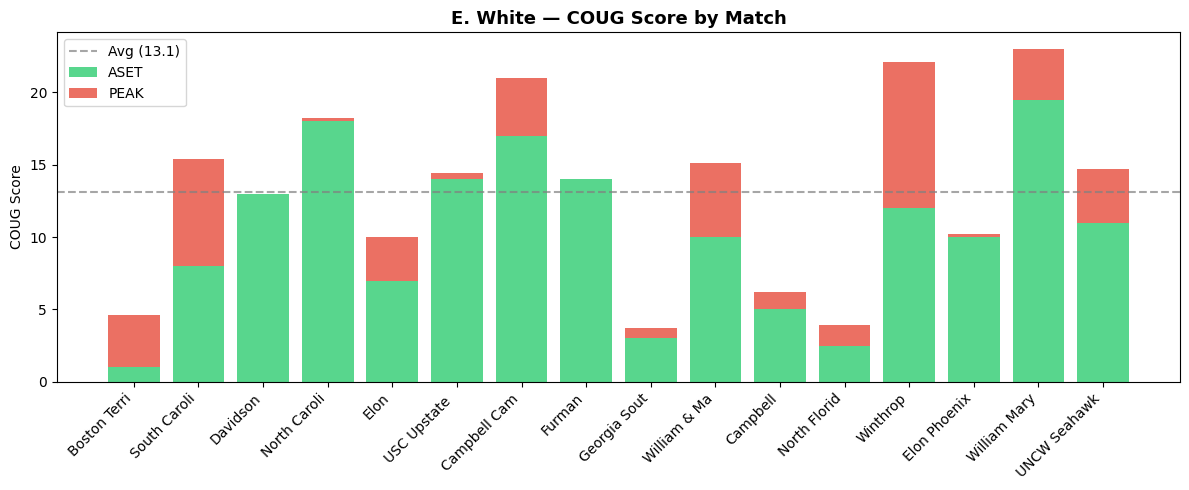

In [7]:
if pdf_files and not season_df.empty:
    # Change to any player name from season_totals
    PLAYER = season_totals.iloc[0]['player']  # defaults to top scorer

    player_df = season_df[season_df['player'] == PLAYER].copy()

    if not player_df.empty:
        fig, ax = plt.subplots(figsize=(12, 5))

        x = range(len(player_df))
        ax.bar(x, player_df['aset_score'], color='#2ecc71', alpha=0.8, label='ASET')
        ax.bar(x, player_df['peak_score'],
               bottom=player_df['aset_score'], color='#e74c3c', alpha=0.8, label='PEAK')

        labels = [str(row.get('opponent', f'Match {i+1}'))[:12]
                  for i, (_, row) in enumerate(player_df.iterrows())]
        ax.set_xticks(list(x))
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.axhline(player_df['total_score'].mean(), color='gray', linestyle='--',
                   alpha=0.7, label=f'Avg ({player_df["total_score"].mean():.1f})')
        ax.set_title(f'{PLAYER} — COUG Score by Match', fontsize=13, fontweight='bold')
        ax.set_ylabel('COUG Score')
        ax.legend()

        plt.tight_layout()
        plt.savefig(COUG_TABLE_DIR + f'/figures/player_trend_{PLAYER.replace(" ", "_")}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print(f'Player {PLAYER} not found')